## Trust Game 2026 
Model agnostic results: Mann-Whittney U statistic of group differences and plots

In [ ]:
# Preparation
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

df_succ=pd.read_csv("master_3models.csv")

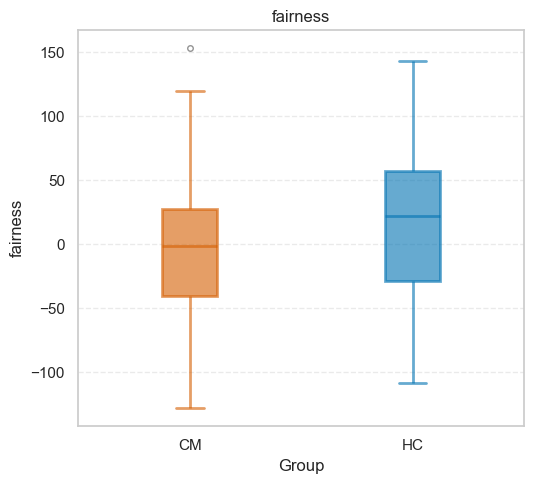

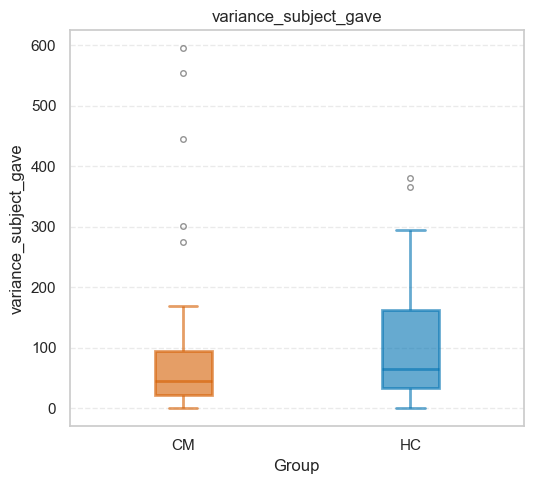

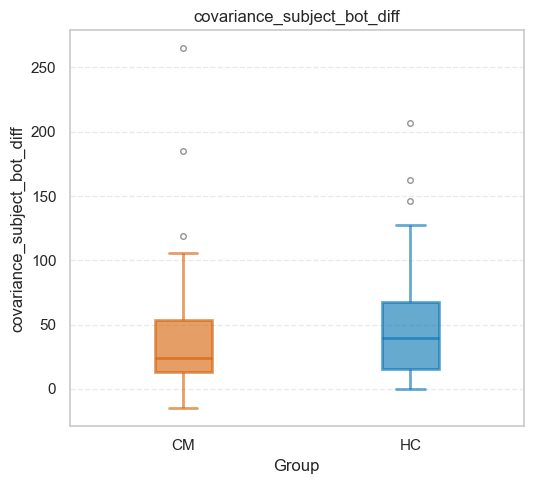

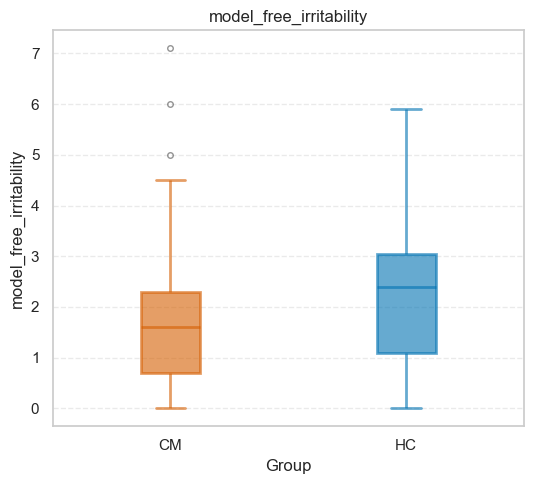

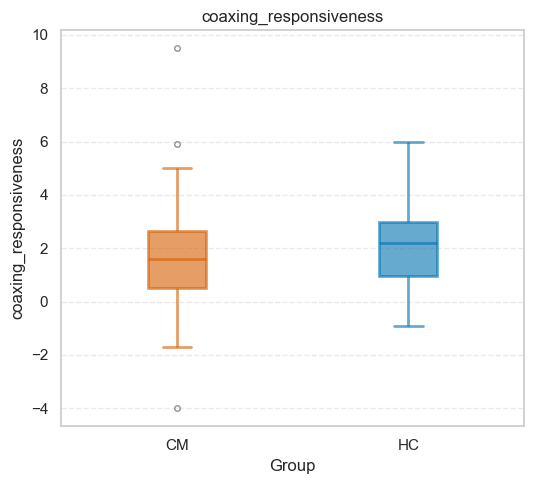

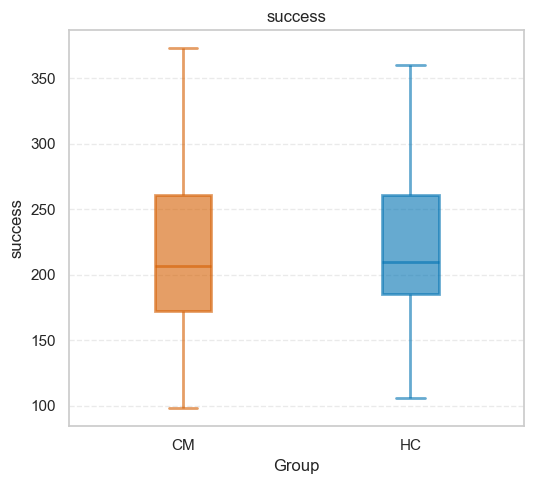

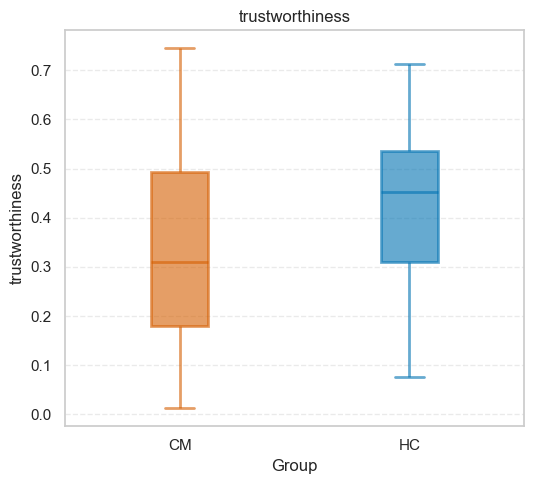

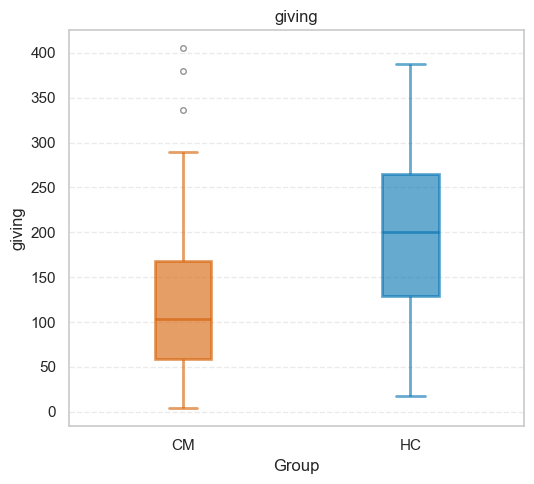

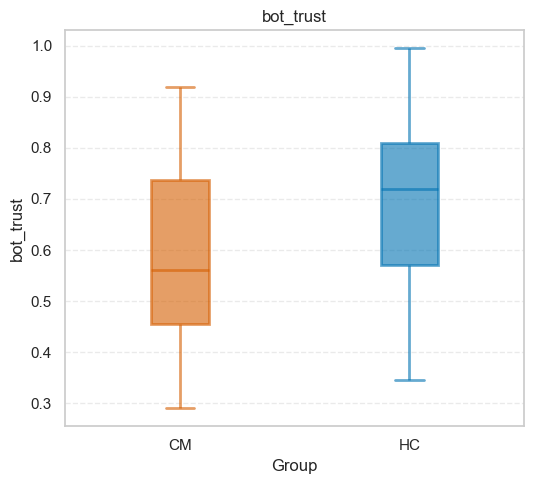

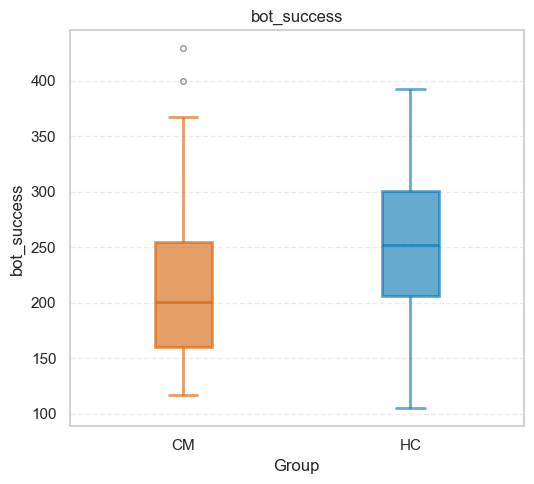

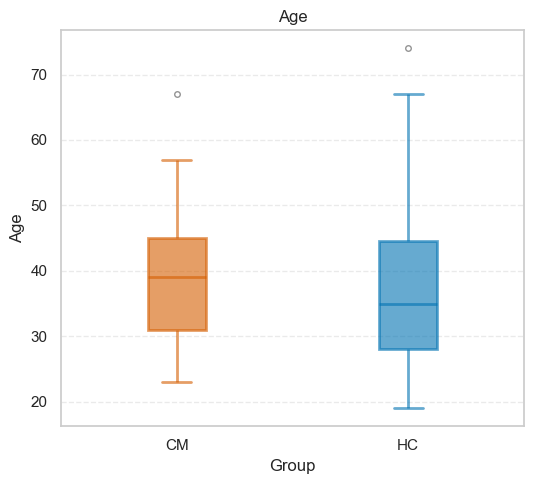

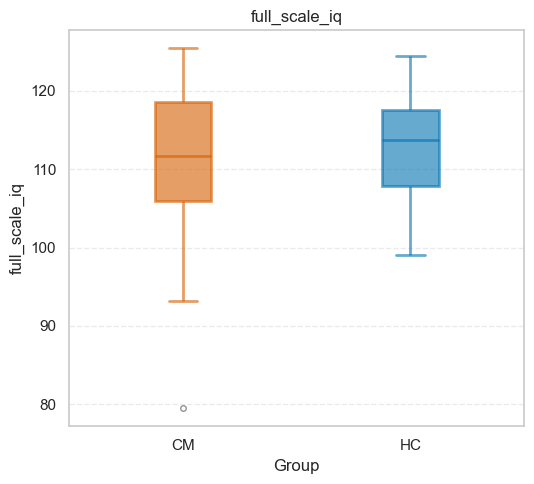

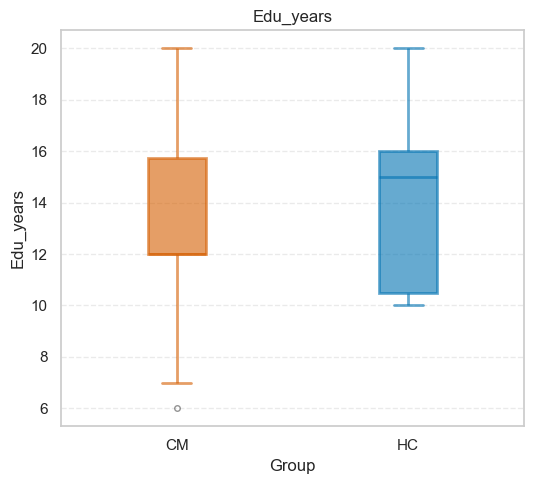

,Variable,U statistic,p-value
0,fairness,1355.0,0.058673
1,variance_subject_gave,1303.0,0.134324
2,covariance_subject_bot_diff,1282.0,0.180748
3,model_free_irritability,1331.0,0.087254
4,coaxing_responsiveness,1308.0,0.124582
5,success,1171.0,0.617699
6,trustworthiness,1477.0,0.004908
7,giving,1566.0,0.000490
8,bot_trust,1481.0,0.004455
9,bot_success,1533.5,0.001194


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

# Seaborn style
sns.set(style='whitegrid')

# Color scheme
group_colors = {
    'HC': '#0072B2',
    'CM': '#D55E00',
}

# Settings
alpha = 0.6
width = 0.25

# Variables to analyze
columns_to_plot = [
    'success',
    'trustworthiness',
    'giving',
    'bot_trust',
    'bot_success'
]

# Storage for results
u_test_results = []

# Loop through each variable
for col in columns_to_plot:
    fig, ax = plt.subplots(figsize=(5.5, 5))

    # Plot
    sns.boxplot(
        data=df_succ,
        x='group_x',
        y=col,
        width=width,
        linewidth=2,
        fliersize=4,
        ax=ax
    )

    groups = df_succ['group_x'].unique()

    # Style boxes
    for patch, group in zip(ax.patches, groups):
        color = group_colors[group]
        patch.set_facecolor(color)
        patch.set_alpha(alpha)
        patch.set_edgecolor(color)
        patch.set_linewidth(2)

    # Style whiskers, caps, medians
    for i, group in enumerate(groups):
        color = group_colors[group]
        for j in range(6):
            line_index = i * 6 + j
            if line_index < len(ax.lines):
                ax.lines[line_index].set_color(color)
                ax.lines[line_index].set_alpha(alpha)
                ax.lines[line_index].set_linewidth(2)

    # Mann–Whitney U test
    hc_vals = df_succ[df_succ['group_x'] == 'HC'][col].dropna()
    cm_vals = df_succ[df_succ['group_x'] == 'CM'][col].dropna()

    try:
        u_stat, p_val = mannwhitneyu(hc_vals, cm_vals, alternative='two-sided')
        u_test_results.append({
            'Variable': col,
            'U statistic': u_stat,
            'p-value': p_val
        })
    except ValueError:
        u_test_results.append({
            'Variable': col,
            'U statistic': None,
            'p-value': None
        })

    # Plot formatting
    ax.set_xlabel('Group')
    ax.set_ylabel(col)
    ax.set_title(f'{col}')
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()

# === Display U test results as a table ===
import pandas as pd
from IPython.display import display

results_df = pd.DataFrame(u_test_results)
display(results_df)
